# BBO12_Enhanced: GP+UCB with Selective Clustering + PCA-Analogy Enhancements

Built on BBO11_2. Five PCA-analogy enhancements added:

| ID | Enhancement | PCA Analogue |
|----|-------------|---------------|
| E1 | Uncertainty gradient direction | First eigenvector of variance field |
| E2 | ARD length-scale extraction | Eigenvalue spectrum |
| E3 | PCA pre-projection for d≥5 | Dimensionality reduction before clustering |
| E4 | PCA-stratified candidate generation | PC-aligned sampling |
| E5 | Cluster-local PCA gap direction | Within-cluster principal axis |

Retained from BBO11_2: CV kernel selection, silhouette-gated clustering (#9–#11), L-BFGS-B refinement.

In [1]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.optimize import minimize
from scipy.spatial.distance import cdist

print("BBO12_Enhanced imports OK")

BBO12_Enhanced imports OK


## Part 1: GP Infrastructure

CV-based kernel selection over RBF, Matérn-2.5, Matérn-1.5. No HPO (< 0.001 CV gain observed across F1–F8).

In [2]:
def fit_best_gp(X_obs, y_obs):
    """
    Select the best GP kernel using cross-validated negative MSE.
    Tries three ARD kernels: RBF, Matern-2.5, Matern-1.5 (all with WhiteKernel).
    Returns: kernel_name, fitted GaussianProcessRegressor, cv_score.
    """
    dim = X_obs.shape[1]
    candidates = {
        "RBF":   (ConstantKernel(1.0, (0.1, 10.0)) *
                  RBF(np.ones(dim), (0.01, 20.0)) +
                  WhiteKernel(1e-5, (1e-10, 1e-2))),
        "Mat25": (ConstantKernel(1.0, (0.1, 10.0)) *
                  Matern(np.ones(dim), (0.01, 20.0), nu=2.5) +
                  WhiteKernel(1e-5, (1e-10, 1e-2))),
        "Mat15": (ConstantKernel(1.0, (0.1, 10.0)) *
                  Matern(np.ones(dim), (0.01, 20.0), nu=1.5) +
                  WhiteKernel(1e-5, (1e-10, 1e-2))),
    }
    best_name, best_gp, best_score = None, None, -np.inf
    for name, kernel in candidates.items():
        try:
            gp = GaussianProcessRegressor(
                kernel=kernel, alpha=1e-6,
                n_restarts_optimizer=5, normalize_y=True
            )
            if len(X_obs) >= 5:
                score = cross_val_score(
                    gp, X_obs, y_obs,
                    cv=min(5, len(X_obs)),
                    scoring="neg_mean_squared_error"
                ).mean()
            else:
                gp.fit(X_obs, y_obs)
                score = gp.score(X_obs, y_obs)
            gp.fit(X_obs, y_obs)
            if score > best_score:
                best_score, best_name, best_gp = score, name, gp
        except Exception:
            pass
    return best_name, best_gp, best_score

## E2: ARD Length-Scale Extraction

Normalised inverse ARD length scales as dimension-importance weights. Short length scale → high sensitivity → high weight. Analogue of PCA eigenvalue spectrum.

In [3]:
def get_ard_weights(gp, verbose=True):
    """
    E2: Extract normalised inverse ARD length scales.
    Returns (d,) array normalised to sum=1, or None if extraction fails.
    """
    try:
        ls = gp.kernel_.k1.k2.length_scale
        inv_ls  = 1.0 / np.atleast_1d(ls)
        weights = inv_ls / inv_ls.sum()
        if verbose:
            top = np.argsort(weights)[::-1][:3]
            print(f"  [E2 ARD] Top sensitive dims: "
                  f"{[f'd{i}={weights[i]:.3f}' for i in top]}")
        return weights
    except AttributeError:
        return None

## E4: PCA-Stratified Candidate Generation

30% of candidates are PCA-aligned perturbations around observed points, scaled by sqrt(explained_variance). 70% remain uniform. Concentrates acquisition search where the function has demonstrated structure.

In [4]:
def pca_stratified_candidates(X_obs, bounds, n_random=20_000,
                               pca_fraction=0.30, seed=42, verbose=True):
    """
    E4: Candidates combining uniform draws with PCA-aligned perturbations.
    """
    np.random.seed(seed)
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    dim   = len(bounds)
    n_pca  = int(n_random * pca_fraction)
    n_unif = n_random - n_pca
    X_uniform = np.random.uniform(lows, highs, size=(n_unif, dim))
    if len(X_obs) >= max(3, dim):
        n_components = min(dim, len(X_obs) - 1, 5)
        pca = PCA(n_components=n_components)
        pca.fit(X_obs)
        centres = X_obs[np.random.choice(len(X_obs), n_pca)]
        noise   = np.random.randn(n_pca, n_components) * pca.explained_variance_ ** 0.5
        X_pca   = np.clip(centres + noise @ pca.components_, lows, highs)
        if verbose:
            ev = pca.explained_variance_ratio_
            print(f"  [E4 PCA-Cand] {n_components} PCs, "
                  f"var explained: {ev[:3].round(3)} "
                  f"(cumulative {ev.cumsum()[:3].round(3)})")
    else:
        X_pca = np.random.uniform(lows, highs, size=(n_pca, dim))
        if verbose:
            print("  [E4 PCA-Cand] Too few obs for PCA — uniform fallback")
    return np.vstack([X_uniform, X_pca])

## Part 2: Clustering Engine

Enhancements #9 (KMeans promise scoring), #10 (gap injection), #11 (DBSCAN density penalty) from BBO11, plus:

- **E3**: PCA pre-projection before KMeans for d≥5 (retains ≥90% variance)
- **E5**: Gap midpoints projected onto joint first PC of bridging cluster pair

Silhouette threshold: **0.22**

In [5]:
SILHOUETTE_THRESHOLD = 0.22
PCA_DIM_THRESHOLD    = 5


def analyse_clusters(X_obs, y_obs, bounds, max_k=6,
                     verbose=True, use_pca_projection=True):
    """
    Cluster analysis with E3 (PCA pre-projection) and E5 (PCA gap direction).
    Returns None if silhouette < SILHOUETTE_THRESHOLD.
    """
    n, dim = X_obs.shape
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    Xn    = (X_obs - lows) / (highs - lows + 1e-12)
    if n < 4:
        if verbose: print("  [Cluster] Too few observations — skipped")
        return None

    # E3: PCA pre-projection
    pca_proj = None
    if use_pca_projection and dim >= PCA_DIM_THRESHOLD and n > dim:
        pca_proj   = PCA(n_components=0.90)
        Xn_cluster = pca_proj.fit_transform(Xn)
        if verbose:
            k_eff   = Xn_cluster.shape[1]
            var_ret = pca_proj.explained_variance_ratio_.sum()
            print(f"  [E3 PCA-Proj] {dim}D → {k_eff}D ({var_ret:.1%} variance retained)")
    else:
        Xn_cluster = Xn

    # #9: KMeans k*
    best_k, best_sil, best_km = 2, -1.0, None
    for k in range(2, max(2, min(max_k, n - 1)) + 1):
        km     = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(Xn_cluster)
        if len(np.unique(labels)) < 2:
            continue
        sil = silhouette_score(Xn_cluster, labels)
        if sil > best_sil:
            best_sil, best_k, best_km = sil, k, km

    if best_sil < SILHOUETTE_THRESHOLD:
        if verbose:
            print(f"  [Cluster] Silhouette={best_sil:.3f} < {SILHOUETTE_THRESHOLD} "
                  f"— clustering not used (data too uniform in {dim}D)")
        return None

    labels  = best_km.labels_
    promise = np.array([
        0.4 * np.max(y_obs[labels == c]) +
        0.3 * np.mean(y_obs[labels == c]) +
        0.3 * (1.0 - np.sum(labels == c) / n)
        for c in range(best_k)
    ])
    cscores = (promise - promise.min()) / (promise.max() - promise.min() + 1e-12)

    if verbose:
        print(f"  [Cluster #9] k*={best_k}  silhouette={best_sil:.3f}")
        for c in range(best_k):
            mc = labels == c
            print(f"    Cluster {c}: n={mc.sum():2d}  "
                  f"max_y={y_obs[mc].max():.4f}  promise={cscores[c]:.3f}")

    # #10 + E5: Gap midpoints with PCA direction
    gap_mids, gap_sc = [], []
    for i in range(best_k):
        for j in range(i + 1, best_k):
            Xi_n = Xn[labels == i]
            Xj_n = Xn[labels == j]
            if len(Xi_n) == 0 or len(Xj_n) == 0:
                continue
            D      = cdist(Xi_n, Xj_n)
            ii, jj = np.unravel_index(np.argmin(D), D.shape)
            try:
                pca_local = PCA(n_components=1)
                pca_local.fit(np.vstack([Xi_n, Xj_n]))
                raw_mid   = (Xi_n[ii] + Xj_n[jj]) / 2.0
                pc1       = pca_local.components_[0]
                proj_coef = np.dot(raw_mid - pca_local.mean_, pc1)
                mid_n     = np.clip(pca_local.mean_ + proj_coef * pc1, 0.0, 1.0)
                if verbose:
                    print(f"  [E5 Gap-PCA] Pair ({i},{j}) "
                          f"deviation={np.linalg.norm(mid_n - raw_mid):.4f}")
            except Exception:
                mid_n = (Xi_n[ii] + Xj_n[jj]) / 2.0
            gap_mids.append(mid_n * (highs - lows) + lows)
            gap_sc.append(0.5 * (cscores[i] + cscores[j]) * D[ii, jj])

    if gap_mids:
        gap_mids = np.array(gap_mids)
        gap_sc   = np.array(gap_sc)
        top      = np.argsort(gap_sc)[::-1][:8]
        gap_mids, gap_sc = gap_mids[top], gap_sc[top]
        if verbose:
            print(f"  [Cluster #10+E5] {len(gap_mids)} gap midpoints injected "
                  f"(top score={gap_sc[0]:.4f})")
    else:
        gap_mids = np.empty((0, dim))
        gap_sc   = np.empty(0)

    # #11: DBSCAN
    D_nn = cdist(Xn, Xn)
    np.fill_diagonal(D_nn, np.inf)
    eps  = max(float(np.percentile(D_nn.min(axis=1), 25)), 1e-4)
    db   = DBSCAN(eps=eps, min_samples=max(2, int(0.1 * n))).fit(Xn)
    core_mask = np.zeros(n, dtype=bool)
    core_mask[db.core_sample_indices_] = True
    if verbose:
        n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        print(f"  [Cluster #11] DBSCAN eps={eps:.4f}  "
              f"clusters={n_cl}  core={core_mask.sum()}  "
              f"frontier={n - core_mask.sum()}")

    return {
        "k": best_k, "sil": best_sil,
        "km": best_km, "labels": labels, "cscores": cscores,
        "gaps": gap_mids, "gscores": gap_sc,
        "core_mask": core_mask,
        "lows": lows, "highs": highs, "Xn": Xn, "dim": dim,
        "y_obs": y_obs, "pca_proj": pca_proj,
    }


def score_candidates(X_cand, ca, cluster_weight=0.35,
                     gap_bonus=2.0, density_penalty=0.25):
    """Compute [0,1] cluster-awareness multiplier. Uses E3 PCA projection when available."""
    lows, highs = ca["lows"], ca["highs"]
    Xn = (X_cand - lows) / (highs - lows + 1e-12)
    M  = len(X_cand)
    Xn_cluster = ca["pca_proj"].transform(Xn) if ca["pca_proj"] is not None else Xn
    nc     = np.argmin(cdist(Xn_cluster, ca["km"].cluster_centers_), axis=1)
    scores = (1 - cluster_weight) * np.ones(M) + cluster_weight * ca["cscores"][nc]
    if len(ca["gaps"]) > 0:
        gn = (ca["gaps"] - lows) / (highs - lows + 1e-12)
        dg = cdist(Xn, gn)
        for gi in range(len(ca["gaps"])):
            scores[dg[:, gi] < 0.10] += gap_bonus * ca["gscores"][gi]
    if ca["core_mask"].sum() > 0:
        med      = np.median(ca["y_obs"])
        low_core = ca["core_mask"] & (ca["y_obs"] < med)
        if low_core.sum() > 0:
            D2 = cdist(ca["Xn"], ca["Xn"])
            np.fill_diagonal(D2, np.inf)
            eps2 = max(float(np.percentile(D2.min(axis=1), 25)), 1e-4)
            dl   = cdist(Xn, ca["Xn"][low_core])
            scores[(dl < eps2).any(axis=1)] *= (1.0 - density_penalty)
    s_min, s_max = scores.min(), scores.max()
    return (scores - s_min) / (s_max - s_min + 1e-12)

## E1: Uncertainty Gradient Direction

Finite-difference gradient of GP variance — unit vector toward steepest uncertainty increase. Applied as a post-L-BFGS-B perturbation to catch high-variance regions the mean-surface optimiser misses. Analogue of PCA's first eigenvector.

In [6]:
def uncertainty_gradient_direction(gp, x, bounds, eps=1e-4):
    """
    E1: Unit vector toward steepest GP variance increase from x.
    Uses central finite differences. Returns (grad_unit, base_std).
    """
    x     = np.atleast_1d(x.copy())
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    _, base_std = gp.predict(x.reshape(1, -1), return_std=True)
    base_std    = base_std.item()
    grads = []
    for i in range(len(x)):
        xp = x.copy(); xp[i] = np.clip(x[i] + eps, lows[i], highs[i])
        xm = x.copy(); xm[i] = np.clip(x[i] - eps, lows[i], highs[i])
        _, sp = gp.predict(xp.reshape(1, -1), return_std=True)
        _, sm = gp.predict(xm.reshape(1, -1), return_std=True)
        grads.append((sp.item() - sm.item()) / (2 * eps))
    g    = np.array(grads)
    norm = np.linalg.norm(g)
    return (g / norm if norm > 1e-10 else g), base_std


def apply_uncertainty_gradient_step(gp, x, bounds,
                                     step_sizes=(0.01, 0.02, 0.05),
                                     kappa=4.0, verbose=True):
    """
    E1: Post-perturb candidate along uncertainty gradient direction.
    Keeps result only if UCB improves.
    """
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    span  = highs - lows
    grad_dir, base_std = uncertainty_gradient_direction(gp, x, bounds)
    mu0, std0 = gp.predict(x.reshape(1, -1), return_std=True)
    best_val  = mu0.item() + kappa * std0.item()
    best_x    = x.copy()
    improved  = False
    for step in step_sizes:
        x_trial     = np.clip(x + step * span * grad_dir, lows, highs)
        mu_t, std_t = gp.predict(x_trial.reshape(1, -1), return_std=True)
        ucb_t       = mu_t.item() + kappa * std_t.item()
        if ucb_t > best_val:
            best_val = ucb_t
            best_x   = x_trial
            improved = True
    if verbose and improved:
        delta = np.linalg.norm(best_x - x)
        print(f"  [E1 UncertGrad] Gradient step improved UCB by "
              f"{best_val - (mu0.item() + kappa * std0.item()):+.6f}  "
              f"|Δx|={delta:.5f}  base_std={base_std:.5f}")
    elif verbose:
        print(f"  [E1 UncertGrad] No improvement from gradient step "
              f"(base_std={base_std:.5f})")
    return best_x, improved

## Part 3: Acquisition

UCB + optional cluster blend + L-BFGS-B + E1 gradient step. E4 PCA-stratified candidates replace pure uniform sampling.

In [7]:
def normalize(x):
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 0 else np.zeros_like(x)


def acquire_next_point(
    gp, bounds,
    cluster_analysis=None,
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    X_obs=None,
    seed=42,
    verbose=True,
):
    """
    Select next query point via UCB.
    Pipeline: E4 candidates → gap injection → UCB+cluster blend
              → L-BFGS-B → E1 gradient step.
    """
    np.random.seed(seed)
    dim   = len(bounds)
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])

    # 1. Candidate generation (E4)
    if X_obs is not None and len(X_obs) >= max(3, dim):
        X_cand = pca_stratified_candidates(
            X_obs, bounds, n_random=n_random,
            pca_fraction=0.30, seed=seed, verbose=verbose
        )
    else:
        X_cand = np.random.uniform(lows, highs, size=(n_random, dim))

    # 2. Gap injection
    if cluster_analysis is not None and len(cluster_analysis["gaps"]) > 0:
        X_cand = np.vstack([X_cand, cluster_analysis["gaps"]])

    # 3. UCB + cluster blend
    mu, std  = gp.predict(X_cand, return_std=True)
    ucb_norm = normalize(mu + kappa * std)
    if cluster_analysis is not None:
        cs    = score_candidates(X_cand, cluster_analysis)
        final = (1 - cluster_acq_weight) * ucb_norm + cluster_acq_weight * cs
    else:
        final = ucb_norm

    # 4. Best candidate + L-BFGS-B
    best_idx   = np.argmax(final)
    next_point = X_cand[best_idx].copy()

    def neg_ucb(x):
        mu_, std_ = gp.predict(np.atleast_2d(x), return_std=True)
        return -(float(mu_[0]) + kappa * float(std_[0]))

    result = minimize(neg_ucb, x0=next_point, method="L-BFGS-B", bounds=bounds)
    if result.success:
        next_point = result.x

    # 5. E1: Uncertainty gradient step
    next_point, _ = apply_uncertainty_gradient_step(
        gp, next_point, bounds, kappa=kappa, verbose=verbose
    )

    mu_f, std_f = gp.predict(next_point.reshape(1, -1), return_std=True)
    return next_point, float(mu_f[0]), float(std_f[0])

## Part 4: Main BBO Pipeline

Four-step pipeline: GP fit → E2 ARD weights → Clustering (E3) → Acquisition (E1 + E4).

In [8]:
def simplified_bbo(
    X_obs, y_obs, bounds,
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    use_clustering=True,
    max_k=6,
    verbose=True,
    fn_label="F?",
):
    """BBO12_Enhanced main pipeline."""
    dim = len(bounds)
    if verbose:
        print("=" * 65)
        print(f"BBO12_Enhanced  —  {fn_label}  ({dim}D, {len(y_obs)} observations)")
        print("=" * 65)

    # Step 1: GP
    if verbose: print("\n── Step 1: GP kernel selection")
    kname, gp, cv_score = fit_best_gp(X_obs, y_obs)
    if verbose: print(f"  Best kernel: {kname}  CV={cv_score:.4f}")

    # Step 2: E2 ARD weights
    if verbose: print("\n── Step 2: ARD dimension importance (E2)")
    ard_weights = get_ard_weights(gp, verbose=verbose)

    # Step 3: Clustering (E3 inside)
    ca = None
    if use_clustering:
        if verbose: print("\n── Step 3: Cluster analysis (E3 PCA-projection if d>=5)")
        ca = analyse_clusters(X_obs, y_obs, bounds, max_k=max_k, verbose=verbose)
        if ca is None and verbose:
            print("  Clustering skipped — pure UCB acquisition")
    else:
        if verbose: print("\n── Step 3: Clustering disabled")

    # Step 4: Acquisition (E1 + E4)
    if verbose: print("\n── Step 4: Acquisition (E1 gradient + E4 PCA candidates)")
    next_point, mu_f, std_f = acquire_next_point(
        gp, bounds,
        cluster_analysis=ca,
        kappa=kappa,
        cluster_acq_weight=cluster_acq_weight,
        n_random=n_random,
        X_obs=X_obs,
        verbose=verbose,
    )

    ucb_f       = float(mu_f + kappa * std_f)
    best_obs    = np.argmax(y_obs)
    improvement = ucb_f - y_obs[best_obs]

    if verbose:
        print(f"\n{'=' * 65}")
        print(f"RESULTS — {fn_label}")
        print(f"{'=' * 65}")
        print(f"  Kernel:      {kname}  (CV={cv_score:.4f})")
        cluster_str = (f"k*={ca['k']} sil={ca['sil']:.3f}" if ca else "not used")
        print(f"  Clustering:  {cluster_str}")
        if ard_weights is not None:
            top2 = np.argsort(ard_weights)[::-1][:2]
            print(f"  ARD top dims: {[f'd{i}={ard_weights[i]:.3f}' for i in top2]}")
        print(f"  Next point:  {np.round(next_point, 6)}")
        print(f"  GP mean:     {mu_f:.6f}")
        print(f"  GP std:      {std_f:.6f}")
        print(f"  UCB:         {ucb_f:.6f}")
        print(f"  Current best:{y_obs[best_obs]:.6f}")
        print(f"  Potential Delta: {improvement:+.6f}")

    return {
        "fn_label":         fn_label,
        "next_point":       next_point,
        "mean":             mu_f,
        "std":              std_f,
        "ucb":              ucb_f,
        "kernel":           kname,
        "cv_score":         cv_score,
        "cluster_analysis": ca,
        "ard_weights":      ard_weights,
        "improvement":      improvement,
        "gp":               gp,
    }

## Part 5: Run All Functions (F1–F8)

In [9]:
def run_all(
    functions_to_run=None,
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    use_clustering=True,
    max_k=6,
    data_dir=".",
    save_dir=".",
):
    if functions_to_run is None:
        functions_to_run = list(range(1, 9))

    print("\n" + "=" * 70)
    print("BBO12_Enhanced: GP+UCB WITH SELECTIVE CLUSTERING + PCA ENHANCEMENTS")
    print(f"  Clustering:          {use_clustering}  (threshold sil>={SILHOUETTE_THRESHOLD})")
    print(f"  PCA pre-projection:  enabled for d>={PCA_DIM_THRESHOLD}  (E3)")
    print(f"  PCA candidate gen:   30% of {n_random} candidates  (E4)")
    print(f"  Uncertainty gradient:enabled  (E1)")
    print(f"  ARD weight logging:  enabled  (E2)")
    print(f"  kappa:               {kappa}")
    print(f"  cluster_acq_weight:  {cluster_acq_weight}")
    print("=" * 70)

    all_results = {}
    for fn in functions_to_run:
        label = f"F{fn}"
        print(f"\n{'=' * 60}\n# {label}\n{'=' * 60}")
        try:
            X      = np.atleast_2d(np.load(f"{data_dir}/f{fn}initial_inputs.npy"))
            y      = np.asarray(np.load(f"{data_dir}/f{fn}initial_outputs.npy")).ravel()
            bounds = [(0.0, 1.0)] * X.shape[1]
            print(f"Loaded: {len(y)} obs, {X.shape[1]}D")
            res = simplified_bbo(
                X, y, bounds,
                kappa=kappa,
                cluster_acq_weight=cluster_acq_weight,
                n_random=n_random,
                use_clustering=use_clustering,
                max_k=max_k,
                fn_label=label,
            )
            all_results[label] = res
            np.save(f"{save_dir}/f{fn}_next_bbo12.npy", res["next_point"])
            print(f"\n checkmark {label} — next point saved to f{fn}_next_bbo12.npy")
        except FileNotFoundError:
            print(f"  {label}: data files not found")
        except Exception:
            import traceback; traceback.print_exc()

    print(f"\n{'=' * 80}\nSUMMARY\n{'=' * 80}")
    hdr = (f"{'Fn':<5} {'n':<4} {'d':<3} {'Kernel':<8} {'k*':<4} "
           f"{'Sil':<6} {'UCB':<12} {'Delta':<12} {'ARD_top':<10}")
    print(hdr); print("-" * 80)
    for lbl, r in sorted(all_results.items()):
        ca      = r["cluster_analysis"]
        k_s     = str(ca["k"]) if ca else "-"
        sil     = f"{ca['sil']:.3f}" if ca else "-"
        d       = len(r["next_point"])
        n       = len(r["gp"].X_train_) if hasattr(r["gp"], "X_train_") else "?"
        aw      = r.get("ard_weights")
        ard_str = (f"d{np.argmax(aw)}={np.max(aw):.2f}" if aw is not None else "-")
        print(f"{lbl:<5} {n:<4} {d:<3} {r['kernel']:<8} {k_s:<4} "
              f"{sil:<6} {r['ucb']:<12.4f} {r['improvement']:+.4f}  {ard_str}")

    print(f"\n{'=' * 80}\nNEXT QUERY POINTS\n{'=' * 80}")
    for lbl, r in sorted(all_results.items()):
        coords = ", ".join([f"{v:.6f}" for v in r["next_point"]])
        print(f"{lbl}: [{coords}]")
    return all_results

## Run

In [10]:
results = run_all(
    functions_to_run=list(range(1, 9)),
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    use_clustering=True,
    max_k=6,
    data_dir=".",
    save_dir=".",
)
print("\nALL DONE — next points saved as f1_next_bbo12.npy, ...")


BBO12_Enhanced: GP+UCB WITH SELECTIVE CLUSTERING + PCA ENHANCEMENTS
  Clustering:          True  (threshold sil>=0.22)
  PCA pre-projection:  enabled for d>=5  (E3)
  PCA candidate gen:   30% of 20000 candidates  (E4)
  Uncertainty gradient:enabled  (E1)
  ARD weight logging:  enabled  (E2)
  kappa:               4.0
  cluster_acq_weight:  0.25

# F1
Loaded: 22 obs, 2D
BBO12_Enhanced  —  F1  (2D, 22 observations)

── Step 1: GP kernel selection
  Best kernel: Mat15  CV=-0.0000

── Step 2: ARD dimension importance (E2)
  [E2 ARD] Top sensitive dims: ['d1=0.891', 'd0=0.109']

── Step 3: Cluster analysis (E3 PCA-projection if d>=5)
  [Cluster #9] k*=6  silhouette=0.495
    Cluster 0: n= 4  max_y=0.0000  promise=0.502
    Cluster 1: n= 3  max_y=0.0000  promise=0.751
    Cluster 2: n= 6  max_y=0.0000  promise=0.000
    Cluster 3: n= 4  max_y=0.0000  promise=0.502
    Cluster 4: n= 2  max_y=0.0000  promise=1.000
    Cluster 5: n= 3  max_y=0.0000  promise=0.751
  [E5 Gap-PCA] Pair (0,1) devi

## Visualisation

2D projection of the search space showing cluster regions, observed points, centroids, and the next recommended query point.

In [11]:
import matplotlib.pyplot as plt

def plot_with_clusters(X, x_new, n_clusters=None, resolution=200,
                       title="Clustered Search Space"):
    if X.shape[1] > 2:
        X_plot, x_new_plot = X[:, :2], x_new[:2]
    else:
        X_plot, x_new_plot = X, x_new
    if n_clusters is None:
        n_clusters = int(np.sqrt(len(X_plot))) + 2
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_plot)
    xx, yy = np.meshgrid(
        np.linspace(0.0, 1.0, resolution),
        np.linspace(0.0, 1.0, resolution)
    )
    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.2)
    plt.scatter(X_plot[:, 0], X_plot[:, 1], label="Observations", zorder=3)
    plt.scatter(x_new_plot[0], x_new_plot[1], marker="*", s=200,
                color="red", label="Next point", zorder=4)
    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], marker="x", s=100,
                color="black", label="Centroids", zorder=4)
    plt.title(title + " (2D projection)")
    plt.xlabel("x1"); plt.ylabel("x2")
    plt.legend(); plt.tight_layout()
    plt.show()

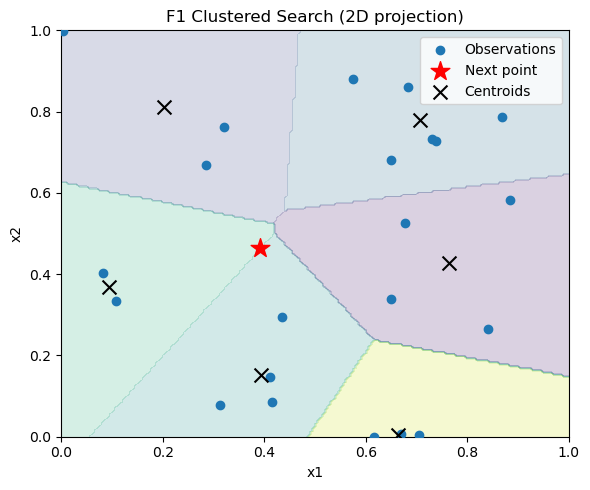

In [12]:
X      = np.load("f1initial_inputs.npy")
x_next = np.load("f1_next_bbo12.npy")
plot_with_clusters(X, x_next, title="F1 Clustered Search")

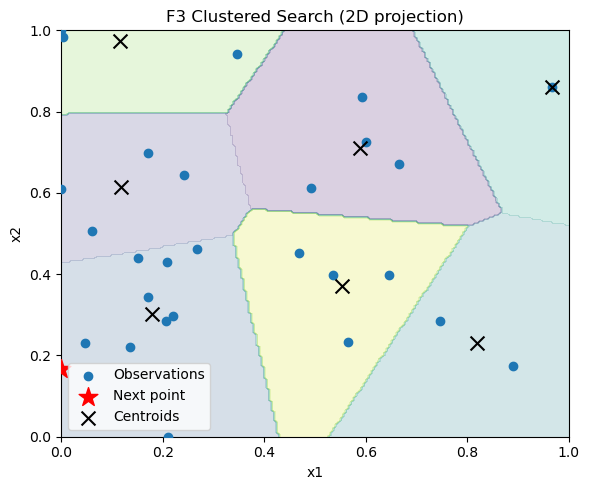

In [13]:
X      = np.load("f3initial_inputs.npy")
x_next = np.load("f3_next_bbo12.npy")
plot_with_clusters(X, x_next, title="F3 Clustered Search")

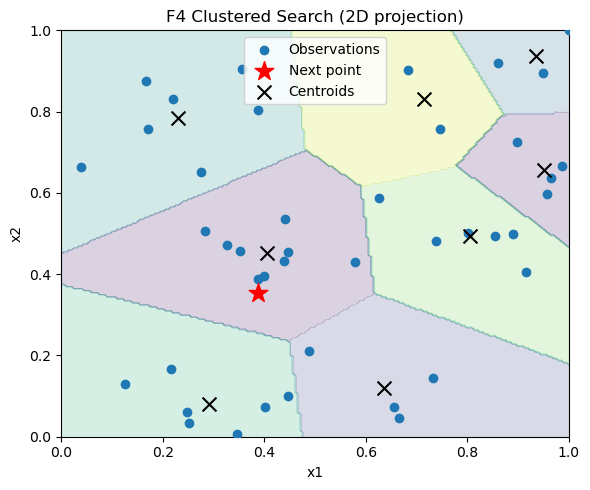

In [14]:
X      = np.load("f4initial_inputs.npy")
x_next = np.load("f4_next_bbo12.npy")
plot_with_clusters(X, x_next, title="F4 Clustered Search")

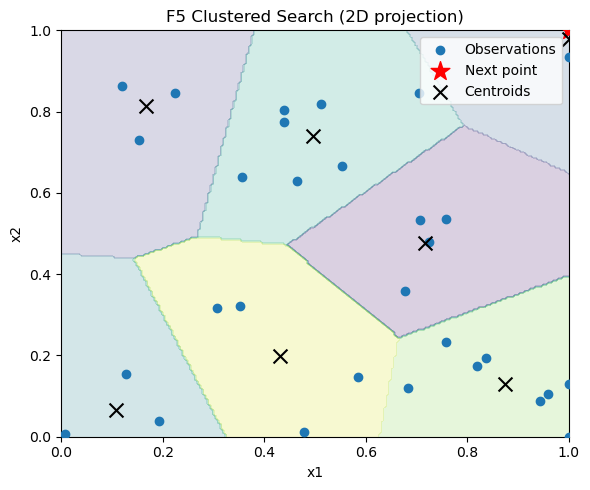

In [15]:
X      = np.load("f5initial_inputs.npy")
x_next = np.load("f5_next_bbo12.npy")
plot_with_clusters(X, x_next, title="F5 Clustered Search")

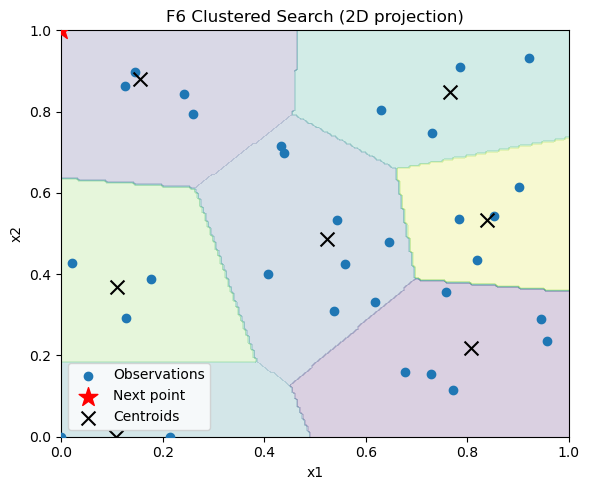

In [16]:
X      = np.load("f6initial_inputs.npy")
x_next = np.load("f6_next_bbo12.npy")
plot_with_clusters(X, x_next, title="F6 Clustered Search")

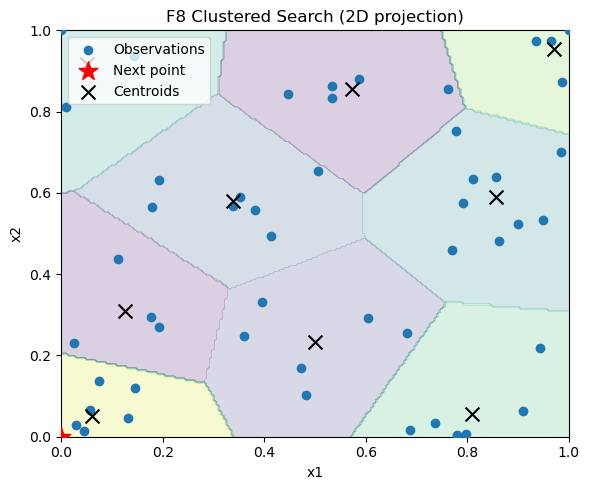

In [17]:
X      = np.load("f8initial_inputs.npy")
x_next = np.load("f8_next_bbo12.npy")
plot_with_clusters(X, x_next, title="F8 Clustered Search")